# SmartGridAI — Phase 2: Feature Engineering & Baseline Forecasting

Builds timestamp / lag / rolling features on the Phase 1 cleaned series, applies a strictly chronological train/validation/test split (no shuffle), and evaluates three naive baselines (previous-hour, previous-day, 24h moving average) with MAE / RMSE / MAPE.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

ROOT = Path.cwd() if (Path.cwd() / "ml").exists() else Path.cwd().parent
PROCESSED = ROOT / "ml" / "data" / "processed"
print("Project root:", ROOT)

Project root: C:\Users\lisha\Desktop\smartgridai


## 1. Feature Matrix Overview

In [2]:
features = pd.read_parquet(PROCESSED / "features_hourly.parquet")
features.index = pd.to_datetime(features.index)

print(f"Feature matrix: {features.shape[0]:,} rows x {features.shape[1]} columns")
print(f"Date range: {features.index.min()}  ->  {features.index.max()}")
print()
splits = json.loads((PROCESSED / "data_splits.json").read_text(encoding="utf-8"))
for name, info in splits["splits"].items():
    print(f"{name:>11}: {info['rows']:>6,} rows  {info['start']}  ->  {info['end']}")
print()
features.groupby("split").size().rename("rows")

Feature matrix: 34,860 rows x 23 columns
Date range: 2015-01-08 05:00:00  ->  2018-12-31 22:00:00

      train: 24,402 rows  2015-01-08 05:00:00  ->  2017-10-22 00:00:00
 validation:  5,229 rows  2017-10-22 01:00:00  ->  2018-05-27 23:00:00
       test:  5,229 rows  2018-05-28 00:00:00  ->  2018-12-31 22:00:00



split
test           5229
train         24402
validation     5229
Name: rows, dtype: int64

## 2. Timestamp Feature Distributions

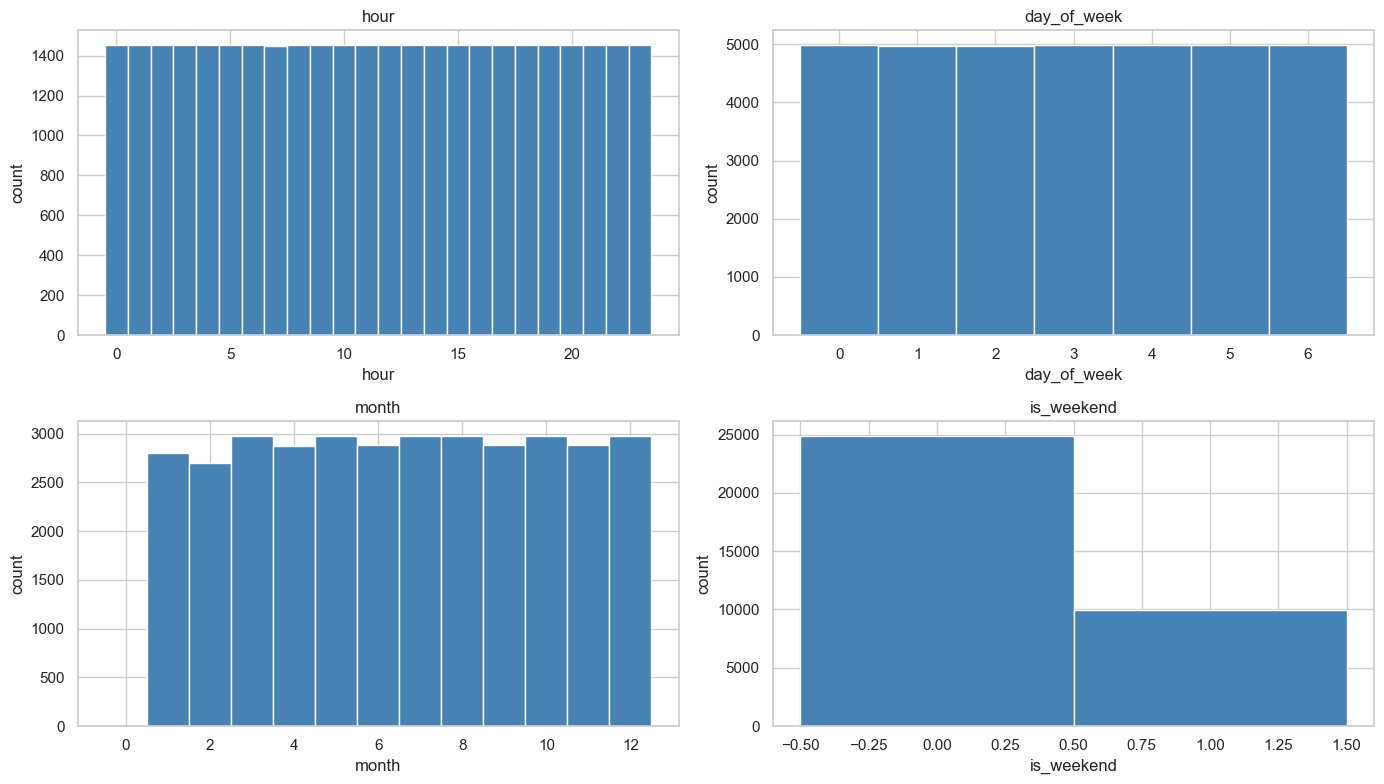

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), ["hour", "day_of_week", "month", "is_weekend"]):
    ax.hist(features[col], bins=np.arange(features[col].max() + 2) - 0.5,
            color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## 3. Lag Relationships (autocorrelation + scatter)

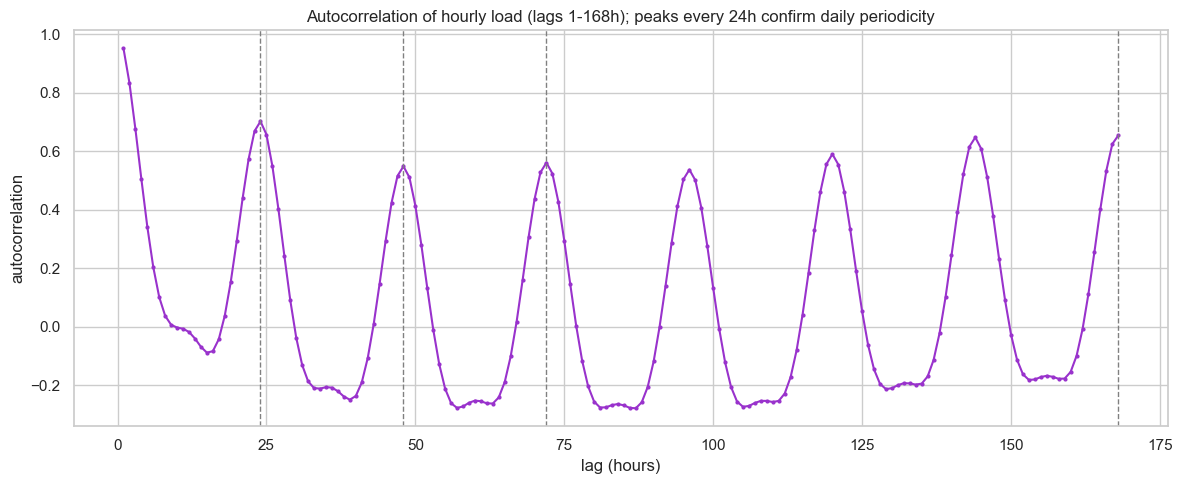

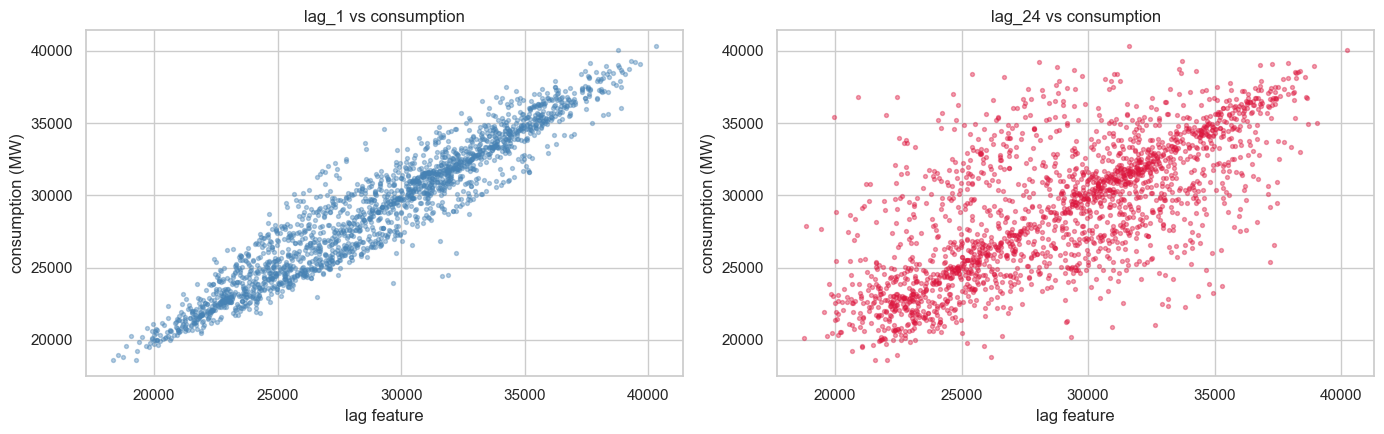

In [4]:
lags = list(range(1, 169))
acf = [features["consumption"].autocorr(lag) for lag in lags]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lags, acf, marker="o", markersize=2, color="darkorchid")
for l in (24, 48, 72, 168):
    ax.axvline(l, color="grey", ls="--", lw=1)
ax.set_title("Autocorrelation of hourly load (lags 1-168h); peaks every 24h confirm daily periodicity")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sample = features.sample(2000, random_state=0)
axes[0].scatter(sample["lag_1"], sample["consumption"], s=8, alpha=0.4, color="steelblue")
axes[0].set_title("lag_1 vs consumption")
axes[1].scatter(sample["lag_24"], sample["consumption"], s=8, alpha=0.4, color="crimson")
axes[1].set_title("lag_24 vs consumption")
for ax in axes:
    ax.set_xlabel("lag feature")
    ax.set_ylabel("consumption (MW)")
plt.tight_layout()
plt.show()

## 4. Rolling Averages

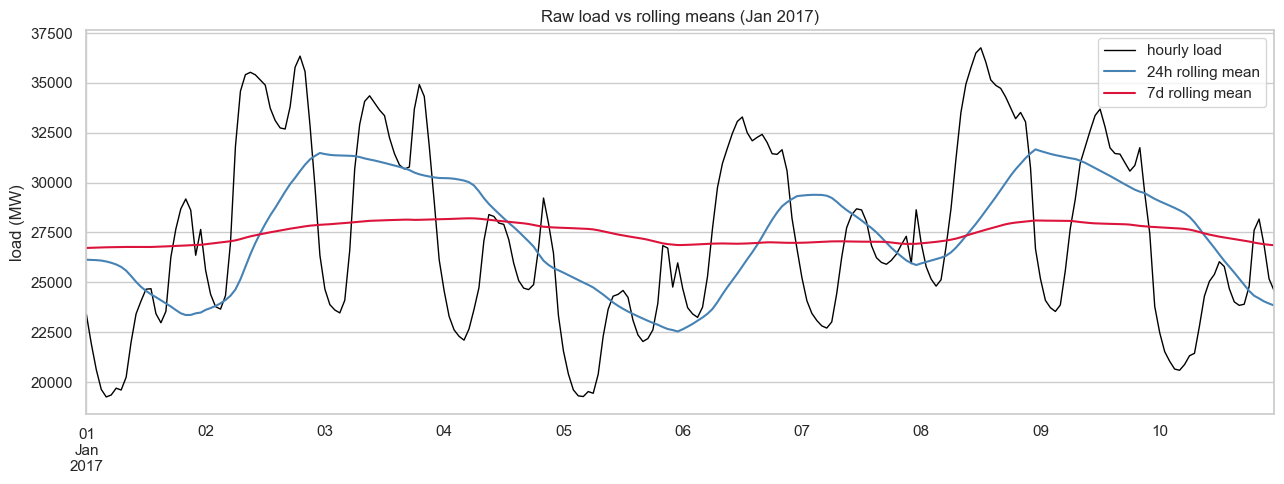

In [5]:
window = features.loc["2017-01-01":"2017-01-10"]
fig, ax = plt.subplots(figsize=(13, 5))
window["consumption"].plot(ax=ax, label="hourly load", color="black", lw=1)
window["rolling_mean_24h"].plot(ax=ax, label="24h rolling mean", color="steelblue", lw=1.5)
window["rolling_mean_7d"].plot(ax=ax, label="7d rolling mean", color="crimson", lw=1.5)
ax.set_title("Raw load vs rolling means (Jan 2017)")
ax.set_ylabel("load (MW)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Consumption Patterns by Split

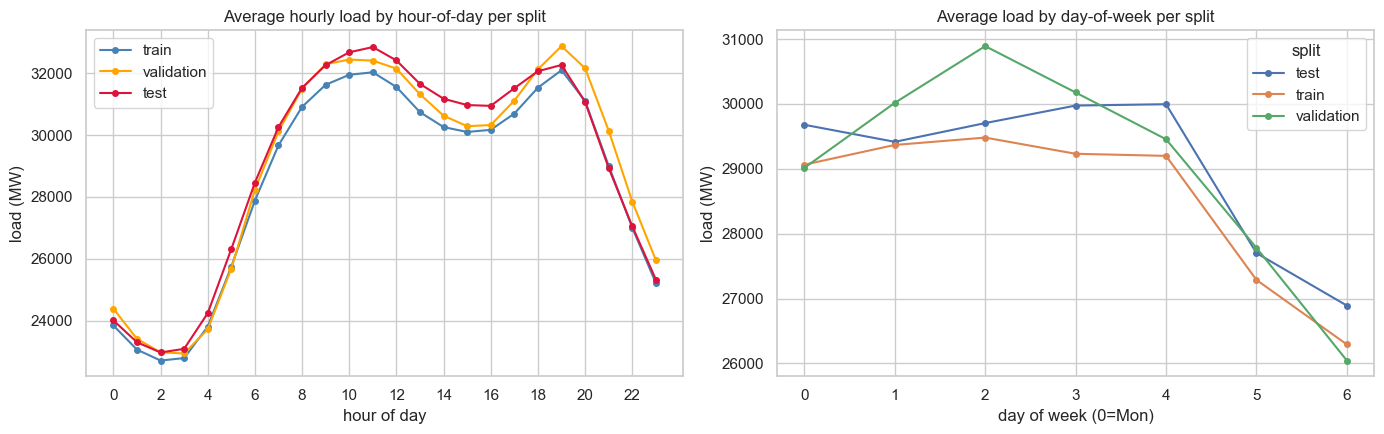

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

hour_series = features.set_index(features.index)
for split, color in zip(["train", "validation", "test"], ["steelblue", "orange", "crimson"]):
    part = hour_series[hour_series["split"] == split]
    prof = part.groupby(part.index.hour)["consumption"].mean()
    axes[0].plot(prof.index, prof.values, marker="o", ms=4, label=split, color=color)
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_title("Average hourly load by hour-of-day per split")
axes[0].set_xlabel("hour of day")
axes[0].set_ylabel("load (MW)")
axes[0].legend()

dow = hour_series.groupby([hour_series.index.dayofweek, "split"])["consumption"].mean().unstack()
dow.index.name = "day_of_week"
dow.plot(ax=axes[1], marker="o", ms=4)
axes[1].set_title("Average load by day-of-week per split")
axes[1].set_xlabel("day of week (0=Mon)")
axes[1].set_ylabel("load (MW)")
plt.tight_layout()
plt.show()

## 6. Baseline Performance

In [7]:
report = json.loads((PROCESSED / "baseline_report.json").read_text(encoding="utf-8"))
print(f"Best baseline (lowest test MAE): {report['best_baseline']['name']}")
print(f"Moving-average window: {report['moving_average_window_hours']}h")
print()
rows = []
for name, res in report["baselines"].items():
    for split in ("validation", "test", "overall_val_test"):
        rows.append({"baseline": name, "split": split, **res[split]})
table = pd.DataFrame(rows).round(2)
table.to_string()

Best baseline (lowest test MAE): previous_hour
Moving-average window: 24h



'         baseline             split      mae     rmse   mape     rows\n0   previous_hour        validation  1114.99  1507.04   3.91      NaN\n1   previous_hour              test  1047.25  1385.71   3.69      NaN\n2   previous_hour  overall_val_test  1081.12  1447.65   3.80  10458.0\n3    previous_day        validation  2445.68  3519.03   8.49      NaN\n4    previous_day              test  2530.83  3624.32   8.75      NaN\n5    previous_day  overall_val_test  2488.25  3572.06   8.62  10458.0\n6  moving_average        validation  3464.07  4182.82  12.52      NaN\n7  moving_average              test  3511.39  4199.27  12.67      NaN\n8  moving_average  overall_val_test  3487.73  4191.05  12.59  10458.0'

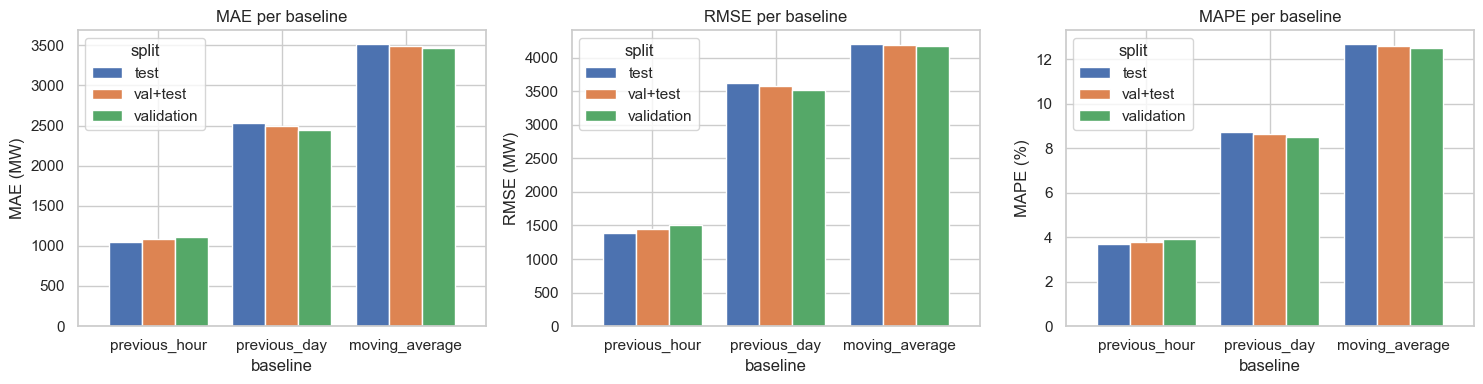

In [8]:
df = table
df["split"] = df["split"].replace({"overall_val_test": "val+test"})
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["mae", "rmse", "mape"]):
    pivot = df.pivot_table(index="baseline", columns="split", values=metric,
                           aggfunc="first").loc[["previous_hour", "previous_day", "moving_average"]]
    pivot.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(f"{metric.upper()} per baseline")
    ax.set_ylabel(metric.upper() + (" (%)" if metric == "mape" else " (MW)"))
    ax.set_xlabel("baseline")
    ax.legend(title="split")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 7. Summary

In [9]:
best = report["best_baseline"]["name"]
res = report["baselines"][best]["test"]
print(f"Features: {features.shape[1] - 1} engineered columns + target + split label")
print(f"Splits (chronological, no shuffle): train {splits['splits']['train']['rows']:,}, "
      f"validation {splits['splits']['validation']['rows']:,}, test {splits['splits']['test']['rows']:,}")
print(f"Best baseline: {best}  ->  test MAE {res['mae']} MW | RMSE {res['rmse']} MW | MAPE {res['mape']}%")
print()
print("Next phase: advanced ML forecasting models (not implemented in Phase 2).")

Features: 22 engineered columns + target + split label
Splits (chronological, no shuffle): train 24,402, validation 5,229, test 5,229
Best baseline: previous_hour  ->  test MAE 1047.25 MW | RMSE 1385.71 MW | MAPE 3.69%

Next phase: advanced ML forecasting models (not implemented in Phase 2).
